# Lag-response grid

This notebook makes Fig. S4: for a spread of (E, τ) configurations of one dyad, it
plots final CCM skill (ρ) as a function of the lag ℓ between TSI and temperature.
Each library-size convergence trajectory from the previous notebook collapses here
into one number: for a given (E, τ), the optimal lag is the positive ℓ (TSI leading
temperature) that maximizes convergent ρ. Only positive lags are considered, since
solar forcing should precede its imprint in temperature rather than the other way
around, following [@Ye:2015aa]. That one number per configuration is what
carries forward into every later multi-dyad comparison.

This notebook builds the conventional CCM lag grid from processed Paleobook outputs.
The real response line and the surrogate scatter come from `delta_rho_stats`, so it
doesn't need the original timeseries or the much larger `delta_rho_full` bootstrap
outputs.

The stored object grid supplies each `(E, tau)` configuration and its annotations.
Its absolute output paths get repaired in memory only, so the grid file itself stays
portable and unchanged.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from cedarkit.viz.panels import LagPlot
from cedarkit.viz.grids import GridPlot
from cedarkit.utils.io.cloudjoblib import joblib_cloud_load
from cedarkit.core.project_config import load_config
from cedarkit.utils.cli.logging import setup_logging
from cedarkit.utils.plotting import save_figure

warnings.filterwarnings("ignore", category=FutureWarning)
notebook_name = "plot__DataGroup_lag"
os.environ["CEDAR_LOG_LEVEL"] = "INFO"
setup_logging(force=True)


## Locate the processed dyad

This expects the copied `tmp/` directory to contain the object-grid joblib and
one `delta_rho_stats` parquet file for each plotted `(E, tau)` pair.


In [2]:
stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])

proj_name = "GISP2Alley00Tanom_Vieira11TSI"
dyad_dir = stem / "hol_temp_tsi_ccm" / proj_name
tmp_dir = dyad_dir / "tmp"
config = load_config(dyad_dir / "proj_config.yaml")

figures_dir = stem / "figures" / notebook_name
figures_dir.mkdir(parents=True, exist_ok=True)
assert tmp_dir.is_dir(), f"Missing processed outputs: {tmp_dir}"
print(f"Using processed outputs in: {tmp_dir}")


Using processed outputs in: /Users/jlanders/PycharmProjects/hol_temp_tsi_ccm_pb/hol_temp_tsi_ccm/GISP2Alley00Tanom_Vieira11TSI/tmp


## Load the grid and rebase output paths

The resolver replaces missing paths beneath the current dyad; it does not
additionally prefer a local copy over an old absolute path that happens to
still be reachable on the plotting machine.


In [3]:
grid_path = tmp_dir / f"{proj_name}_obj_grid__update.joblib"
if not grid_path.exists():
    grid_path = tmp_dir / f"{proj_name}_obj_grid.joblib"
object_grid = joblib_cloud_load(grid_path)


def upgrade_legacy_grid_cell(cell_obj):
    if cell_obj is not None and not hasattr(cell_obj, "_outputs"):
        legacy_output = cell_obj.__dict__.pop("output", None)
        cell_obj._outputs = [] if legacy_output is None else [legacy_output]
    return cell_obj

object_grid_test = {}
for _, cell_obj in object_grid.items():
    cell_obj = upgrade_legacy_grid_cell(cell_obj)
    if cell_obj is None or cell_obj.output is None:
        continue
    output = cell_obj.output
    output.resolve_paths(dyad_dir, prefer_local=False)
    output.set_relationships()
    E, tau = output.grp_config.E, output.grp_config.tau
    if 4 <= E <= 10 and 1 <= tau <= 8:
        object_grid_test[(E, tau)] = cell_obj

print(f"Loaded {len(object_grid_test)} grid cells.")


Loaded 56 grid cells.


## Make a test lag grid

This is a fast, minimal pass -- mean real responses as lines and surrogate
summaries as scatter -- over a small (E, tau) subset, meant to confirm the
plotting pipeline runs against the shipped outputs. Widen `E_values` and
`tau_values` to the full sweep to reproduce the complete grid.


{'TSI (surr) influences temp': '#157F8B', 'TSI influences temp': '#C11123', 'TSI influences temp (surr)': '#FFE096', 'temp (surr) influences TSI': 'steelblue', 'temp influences TSI': '#305996', 'temp influences TSI (surr)': 'dodgerblue', 'TSI (surr) influences d18O': 'firebrick', 'TSI influences d18O': 'red', 'TSI influences d18O (surr)': 'dodgerblue', 'd18O (surr) influences TSI': 'navy', 'd18O influences TSI': 'navy', 'd18O influences TSI (surr)': 'dodgerblue', 'vieira': 'xkcd:orangeish', 'Vieira11TSI': 'xkcd:orangeish', 'Vieira11TSILinear': 'xkcd:dark orange', 'wu': 'darkred', 'Wu18TSI': 'darkred', 'Wu18TSILinear': 'xkcd:indian red', 'erb': 'xkcd:light eggplant', 'Erb22daGMST': 'xkcd:light eggplant', 'Erb22daGMSTLinear': 'xkcd:velvet', 'GISP2Alley00TanomLinear': 'steelblue', 'GISP2multiproxy': 'xkcd:cobalt', 'GISP2Alley00Tanom': 'xkcd:cobalt', 'GISP2Doering22T15N': 'xkcd:deep teal', 'GISP2Doering22T15NLinear': 'xkcd:teal blue', 'GISP2Martin24TanomLinear': 'xkcd:royal', 'GISP2Martin2

/Users/jlanders/PycharmProjects/CCM_software/cedar_util/cedarkit/viz/grids.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


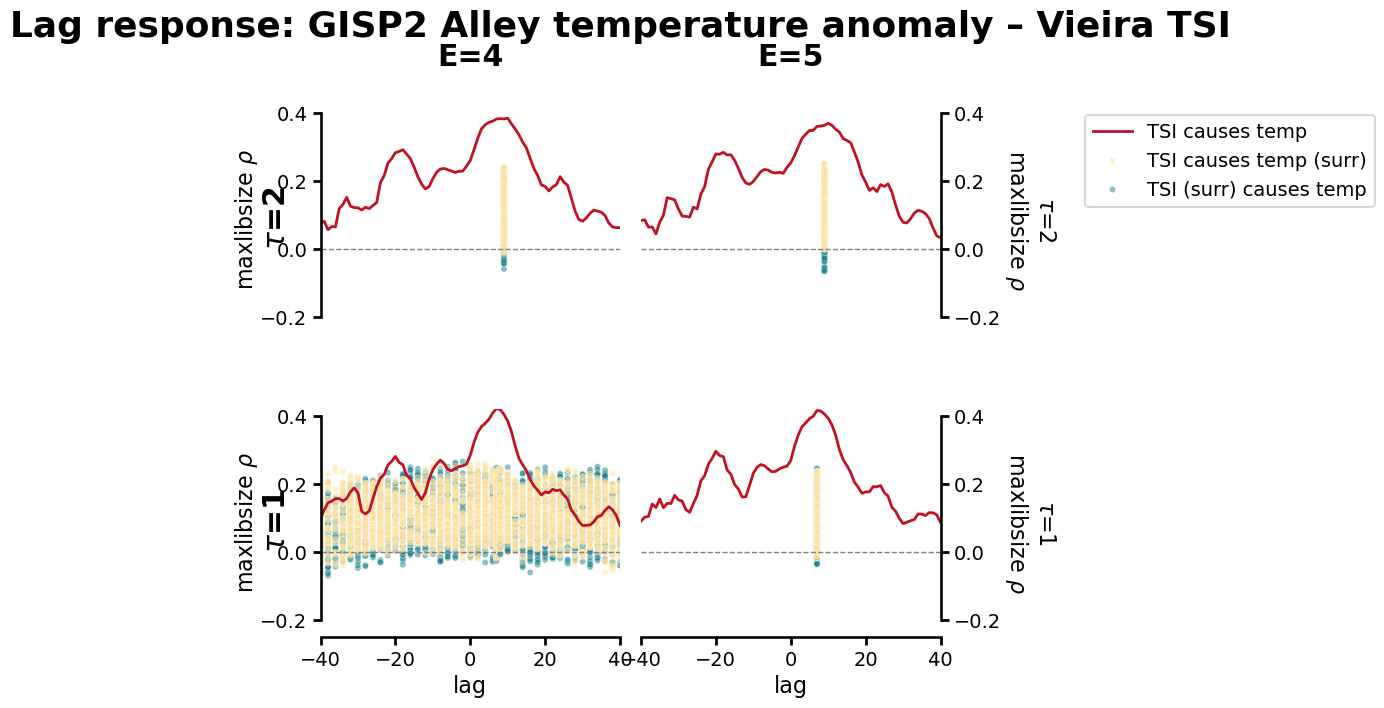

In [4]:
E_values = range(4, 6)
tau_values = range(1, 3)
available_E = [E for E in E_values if any(key[0] == E for key in object_grid_test)]
available_tau = [tau for tau in tau_values if any(key[1] == tau for key in object_grid_test)]
row_var, col_var = 'tau', 'E'
rows, cols = len(available_tau), len(available_E)
gridplot = GridPlot(rows, cols)
gridplot.title = "Lag response: GISP2 Alley temperature anomaly – Vieira TSI"
gridplot.xlims = [-40, 40]
gridplot.make_grid(figsize=(4 * cols, 3 * rows), hspace=.02, context="talk")

for row, row_var_val in enumerate(reversed(available_tau)):
    row_labels = [f"{row_var}={row_var_val}"]
    for col, col_var_val in enumerate(available_E):
        col_labels = [f"{col_var}={col_var_val}"]
        ax = gridplot.get_ax(row, col)

        E= row_var_val if row_var=='E' else col_var_val
        tau = row_var_val if row_var=='tau' else col_var_val
        cell_obj = object_grid_test.get((E, tau))
        if cell_obj is None:
            gridplot.set_ax(row, col, ax, entry_type=None)
            continue
        try:
            lag_plot = LagPlot(ax=ax, palette=config.pal.to_dict(), y_var="maxlibsize_rho")
            lag_plot.make_classic_lag_plot(
                cell_obj.output, stats_only=True, scatter=True, boxplot=False, relation_scope=["r1"]
            )
            print(lag_plot.palette)
            lag_plot.annotations += cell_obj.annotations
            lag_plot.tidy_plot(legend=False)
            lag_plot.ax.set_ylabel('\n'.join(row_labels+lag_plot.ax.get_ylabel().split('\n')))
            lag_plot.ax.set_title('\n'.join(col_labels + [lag_plot.ax.get_title()]))
            gridplot.ylims += [lag_plot.min_y, lag_plot.max_y]
            gridplot.add_handles_labels(lag_plot.scatter_handles, lag_plot.scatter_labels, kind="scatter")
            gridplot.add_handles_labels(lag_plot.line_handles, lag_plot.line_labels, kind="line")
            gridplot.set_ax(row, col, lag_plot.ax, entry_type="plot")
        except Exception as error:
            print(f"Could not plot E={E}, tau={tau}: {error}")
            gridplot.set_ax(row, col, ax, entry_type=None)

gridplot.remove_empty()
gridplot.tidy_rows(add_hline=0, ylim_by="central", title_pad=-5, num_xticks=5, num_yticks=5,
                   supylabel_offset=.07, rlabel_pad=40, titley=1.1)

gridplot.add_legend(bbox_to_anchor=(1.45, 1))
# save_figure(gridplot.fig, figures_dir, stem=f"lag_grid__{proj_name}", dry_run=True)


### Portable data requirement

Keep `proj_config.yaml`, the object-grid joblib, and the desired
`tmp/*__delta_rho_stats__*.parquet` files.  `delta_rho_full` is only required
for the previous exploratory bootstrap-distribution/boxplot workflow, which
is deliberately not part of this slim plot.
